In [1]:
# ============================================================
# NOTEBOOK 02 - MODELO PREDITIVO DE NPS
# NPS Preditivo - Tech Challenge Fase 1 - FIAP PosTech
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             f1_score,
                             roc_auc_score,
                             ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import shap

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120

print("Bibliotecas carregadas com sucesso!")
print(f"\nVersões principais:")
import sklearn; print(f"  scikit-learn: {sklearn.__version__}")
import xgboost; print(f"  xgboost:      {xgboost.__version__}")
print(f"  shap:         {shap.__version__}")

Bibliotecas carregadas com sucesso!

Versões principais:
  scikit-learn: 1.8.0
  xgboost:      3.2.0
  shap:         0.51.0


In [2]:
# ============================================================
# SEÇÃO 2 - CARREGAMENTO E PRÉ-PROCESSAMENTO
# ============================================================

# --- Carregando os dados ---
df = pd.read_csv('../data/raw/desafio_nps_fase_1.csv',
                 sep=None, engine='python')

print(f"Base carregada: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

# --- Criando a target categórica ---
def classificar_nps(score):
    if score <= 6:
        return 'Detrator'
    elif score <= 8:
        return 'Neutro'
    else:
        return 'Promotor'

df['nps_categoria'] = df['nps_score'].apply(classificar_nps)

# --- Removendo variáveis que não devem entrar no modelo ---
colunas_remover = ['customer_id', 'order_id',
                   'nps_score', 'csat_internal_score']

df_modelo = df.drop(columns=colunas_remover)

print(f"\nVariáveis removidas: {colunas_remover}")
print(f"Colunas restantes: {df_modelo.shape[1]}")

# --- Encoding da variável categórica (customer_region) ---
le_regiao = LabelEncoder()
df_modelo['customer_region'] = le_regiao.fit_transform(
    df_modelo['customer_region'])

print(f"\nEncoding de customer_region:")
for i, regiao in enumerate(le_regiao.classes_):
    print(f"  {regiao} → {i}")

# --- Encoding da target ---
le_target = LabelEncoder()
df_modelo['nps_categoria'] = le_target.fit_transform(
    df_modelo['nps_categoria'])

print(f"\nEncoding da target:")
for i, cat in enumerate(le_target.classes_):
    print(f"  {cat} → {i}")

# --- Separando features e target ---
X = df_modelo.drop(columns=['nps_categoria'])
y = df_modelo['nps_categoria']

print(f"\nFeatures (X): {X.shape[1]} variáveis")
print(f"Target  (y): {y.shape[0]:,} registros")
print(f"\nDistribuição da target:")
for i, cat in enumerate(le_target.classes_):
    n = (y == i).sum()
    print(f"  {cat} ({i}): {n:,} ({n/len(y)*100:.1f}%)")

Base carregada: 2,500 linhas × 19 colunas

Variáveis removidas: ['customer_id', 'order_id', 'nps_score', 'csat_internal_score']
Colunas restantes: 16

Encoding de customer_region:
  Centro-Oeste → 0
  Nordeste → 1
  Norte → 2
  Sudeste → 3
  Sul → 4

Encoding da target:
  Detrator → 0
  Neutro → 1
  Promotor → 2

Features (X): 15 variáveis
Target  (y): 2,500 registros

Distribuição da target:
  Detrator (0): 1,851 (74.0%)
  Neutro (1): 448 (17.9%)
  Promotor (2): 201 (8.0%)


In [3]:
# ============================================================
# SEÇÃO 3 - SEPARAÇÃO TREINO / TESTE
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y          # mantém proporção das classes
)

print("=== SEPARAÇÃO TREINO / TESTE ===\n")
print(f"Total de registros:  {len(X):,}")
print(f"Treino (70%):        {len(X_train):,} registros")
print(f"Teste  (30%):        {len(X_test):,} registros")

print(f"\n=== PROPORÇÃO DAS CLASSES ===")
print(f"\n{'Classe':<12} {'Treino':>10} {'Teste':>10}")
print("-" * 34)
for i, cat in enumerate(le_target.classes_):
    n_train = (y_train == i).sum()
    n_test  = (y_test  == i).sum()
    pct_train = n_train / len(y_train) * 100
    pct_test  = n_test  / len(y_test)  * 100
    print(f"{cat:<12} {n_train:>5} ({pct_train:.1f}%)  "
          f"{n_test:>4} ({pct_test:.1f}%)")

print(f"\nProporção mantida entre treino e teste (stratify=y)")
print(f"random_state=42 garante reprodutibilidade")

=== SEPARAÇÃO TREINO / TESTE ===

Total de registros:  2,500
Treino (70%):        1,750 registros
Teste  (30%):        750 registros

=== PROPORÇÃO DAS CLASSES ===

Classe           Treino      Teste
----------------------------------
Detrator      1296 (74.1%)   555 (74.0%)
Neutro         313 (17.9%)   135 (18.0%)
Promotor       141 (8.1%)    60 (8.0%)

Proporção mantida entre treino e teste (stratify=y)
random_state=42 garante reprodutibilidade


=== BASELINE — DUMMY CLASSIFIER ===
Estratégia: sempre chuta a classe mais frequente (Detrator)

              precision    recall  f1-score   support

    Detrator       0.74      1.00      0.85       555
      Neutro       0.00      0.00      0.00       135
    Promotor       0.00      0.00      0.00        60

    accuracy                           0.74       750
   macro avg       0.25      0.33      0.28       750
weighted avg       0.55      0.74      0.63       750

F1-Score (weighted): 0.6294


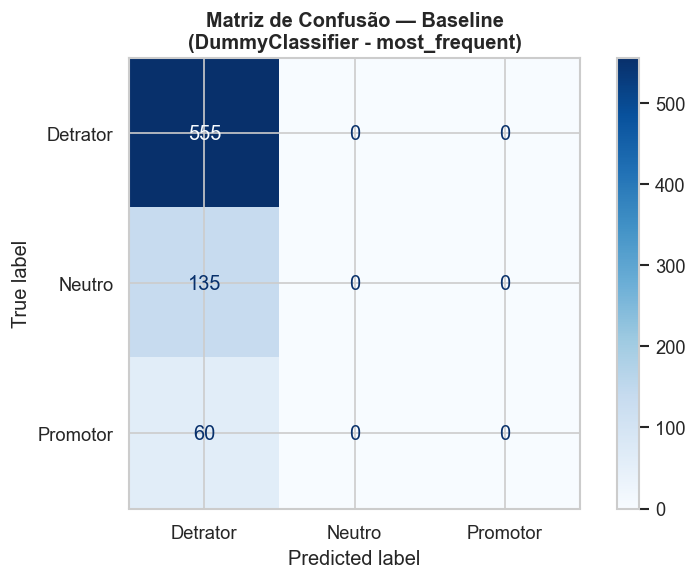


 Baseline nunca prevê Neutro ou Promotor
 Qualquer modelo real precisa superar esse resultado


In [4]:
# ============================================================
# SEÇÃO 4 - MODELO BASELINE (DUMMY CLASSIFIER)
# ============================================================

# Treinando o modelo baseline
baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

print("=== BASELINE — DUMMY CLASSIFIER ===")
print("Estratégia: sempre chuta a classe mais frequente (Detrator)\n")

# Relatório de classificação
print(classification_report(
    y_test, y_pred_baseline,
    target_names=le_target.classes_))

# F1 Score geral
f1_baseline = f1_score(y_test, y_pred_baseline, average='weighted')
print(f"F1-Score (weighted): {f1_baseline:.4f}")

# Matriz de confusão
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_baseline,
    display_labels=le_target.classes_,
    cmap='Blues', ax=ax)
ax.set_title('Matriz de Confusão — Baseline\n'
             '(DummyClassifier - most_frequent)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/07_matriz_baseline.png', bbox_inches='tight')
plt.show()

print("\n Baseline nunca prevê Neutro ou Promotor")
print(" Qualquer modelo real precisa superar esse resultado")

Treinando Random Forest...
(pode demorar alguns segundos)

=== RANDOM FOREST — RESULTADOS ===

              precision    recall  f1-score   support

    Detrator       0.84      0.98      0.91       555
      Neutro       0.76      0.23      0.35       135
    Promotor       0.94      1.00      0.97        60

    accuracy                           0.85       750
   macro avg       0.85      0.74      0.74       750
weighted avg       0.84      0.85      0.81       750

F1-Score (weighted): 0.8130
Melhoria vs Baseline: +0.1836


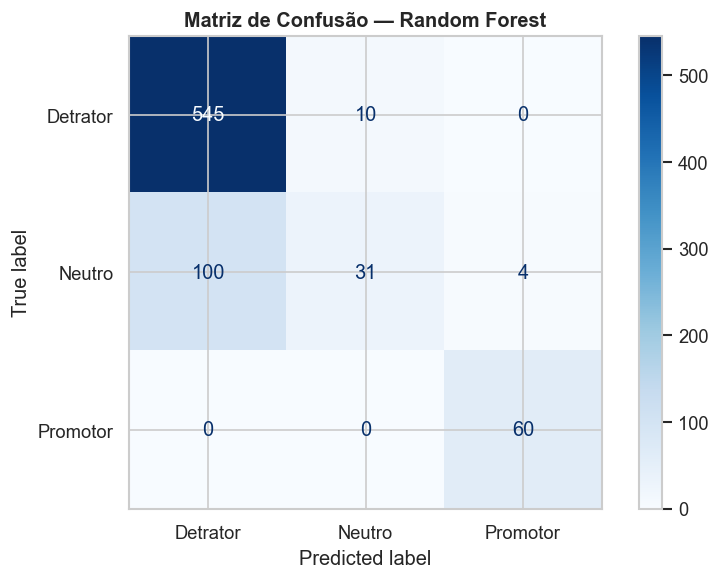

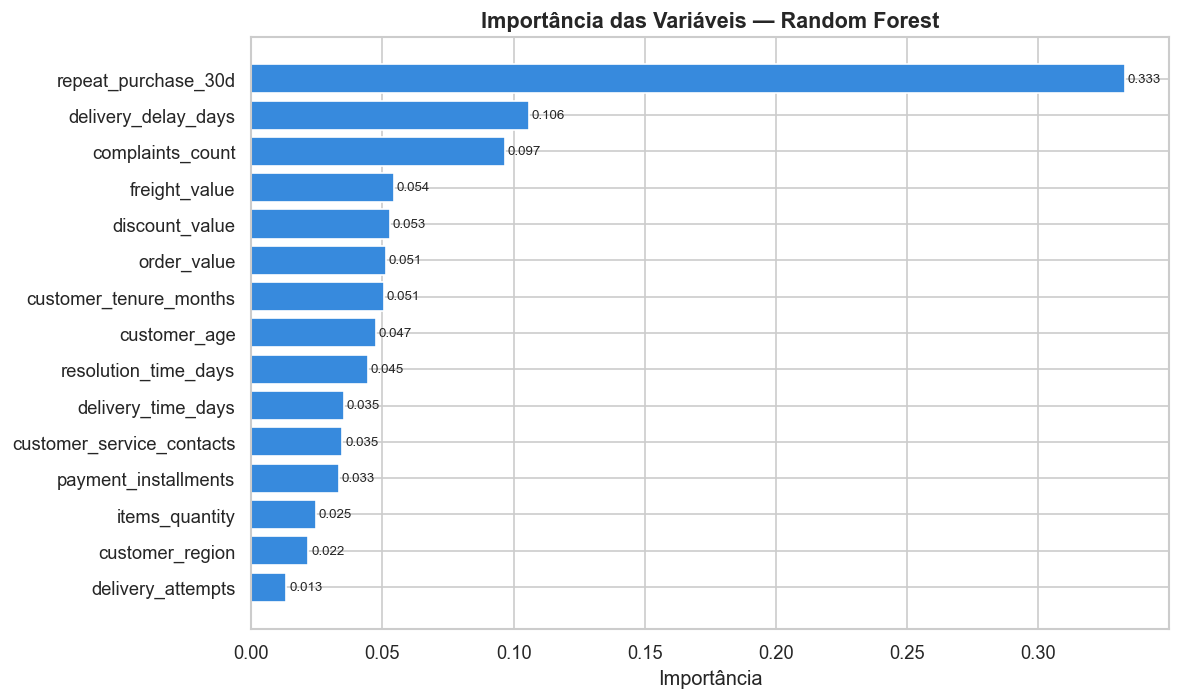

In [5]:
# ============================================================
# SEÇÃO 5 - RANDOM FOREST
# ============================================================

print("Treinando Random Forest...")
print("(pode demorar alguns segundos)\n")

# Treinando o modelo
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== RANDOM FOREST — RESULTADOS ===\n")

# Relatório de classificação
print(classification_report(
    y_test, y_pred_rf,
    target_names=le_target.classes_))

# F1 Score
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
print(f"F1-Score (weighted): {f1_rf:.4f}")
print(f"Melhoria vs Baseline: +{f1_rf - f1_baseline:.4f}")

# Matriz de confusão
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=le_target.classes_,
    cmap='Blues', ax=ax)
ax.set_title('Matriz de Confusão — Random Forest',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/08_matriz_random_forest.png',
            bbox_inches='tight')
plt.show()

# Feature importance
importancias = pd.DataFrame({
    'variavel': X.columns,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importancias['variavel'],
               importancias['importancia'],
               color='#378ADD', edgecolor='white')
ax.set_title('Importância das Variáveis — Random Forest',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importância')
for bar, val in zip(bars, importancias['importancia']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/figures/09_feature_importance_rf.png',
            bbox_inches='tight')
plt.show()

=== PESOS DAS CLASSES (balanceamento) ===
  Detrator: 0.450
  Neutro: 1.864
  Promotor: 4.137

Treinando XGBoost...
(pode demorar alguns segundos)

=== XGBOOST — RESULTADOS ===

              precision    recall  f1-score   support

    Detrator       0.88      0.91      0.89       555
      Neutro       0.54      0.45      0.49       135
    Promotor       0.94      0.97      0.95        60

    accuracy                           0.83       750
   macro avg       0.78      0.78      0.78       750
weighted avg       0.82      0.83      0.82       750

F1-Score (weighted):      0.8249
Melhoria vs Baseline:    +0.1955
Melhoria vs Rand Forest: +0.0120


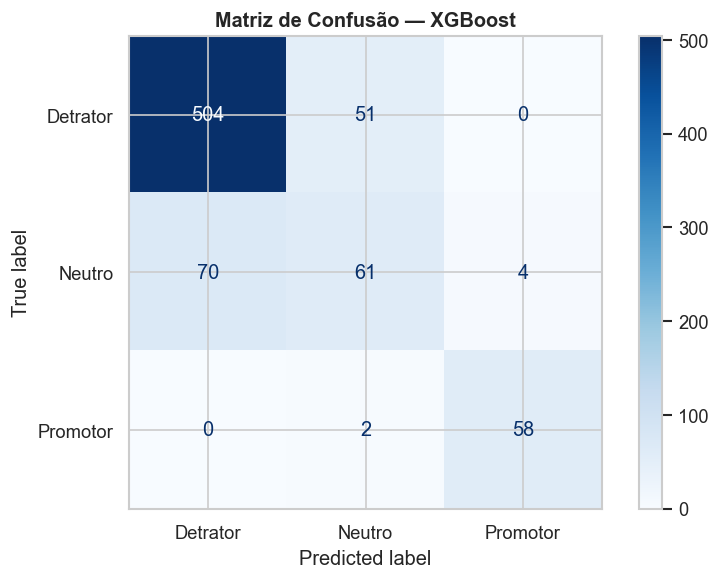

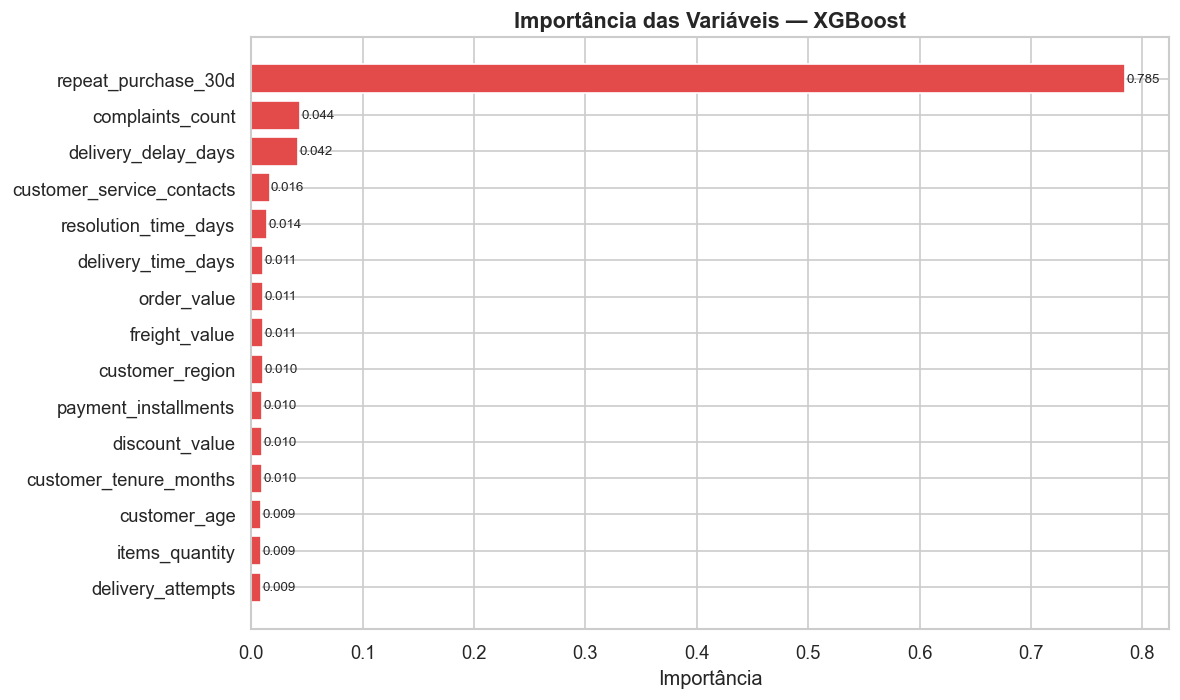

In [6]:
# ============================================================
# SEÇÃO 6 - XGBOOST
# ============================================================

# Calculando pesos para balancear as classes
contagem_classes = np.bincount(y_train)
peso_classes = len(y_train) / (len(contagem_classes) * contagem_classes)

print("=== PESOS DAS CLASSES (balanceamento) ===")
for i, cat in enumerate(le_target.classes_):
    print(f"  {cat}: {peso_classes[i]:.3f}")

# Criando vetor de pesos para cada amostra de treino
sample_weights = np.array([peso_classes[y] for y in y_train])

print("\nTreinando XGBoost...")
print("(pode demorar alguns segundos)\n")

# Treinando o modelo
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    verbosity=0
)
xgb.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_xgb = xgb.predict(X_test)

print("=== XGBOOST — RESULTADOS ===\n")

# Relatório de classificação
print(classification_report(
    y_test, y_pred_xgb,
    target_names=le_target.classes_))

# F1 Score
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')
print(f"F1-Score (weighted):      {f1_xgb:.4f}")
print(f"Melhoria vs Baseline:    +{f1_xgb - f1_baseline:.4f}")
print(f"Melhoria vs Rand Forest: +{f1_xgb - f1_rf:.4f}")

# Matriz de confusão
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=le_target.classes_,
    cmap='Blues', ax=ax)
ax.set_title('Matriz de Confusão — XGBoost',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/10_matriz_xgboost.png', bbox_inches='tight')
plt.show()

# Feature importance XGBoost
importancias_xgb = pd.DataFrame({
    'variavel': X.columns,
    'importancia': xgb.feature_importances_
}).sort_values('importancia', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importancias_xgb['variavel'],
               importancias_xgb['importancia'],
               color='#E24B4A', edgecolor='white')
ax.set_title('Importância das Variáveis — XGBoost',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importância')
for bar, val in zip(bars, importancias_xgb['importancia']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/figures/11_feature_importance_xgb.png',
            bbox_inches='tight')
plt.show()

=== COMPARAÇÃO GERAL DOS MODELOS ===

       Modelo  F1 Geral  F1 Detrator  F1 Neutro  F1 Promotor
     Baseline    0.6294       0.8506     0.0000       0.0000
Random Forest    0.8130       0.9083     0.3523       0.9677
      XGBoost    0.8249       0.8928     0.4900       0.9508


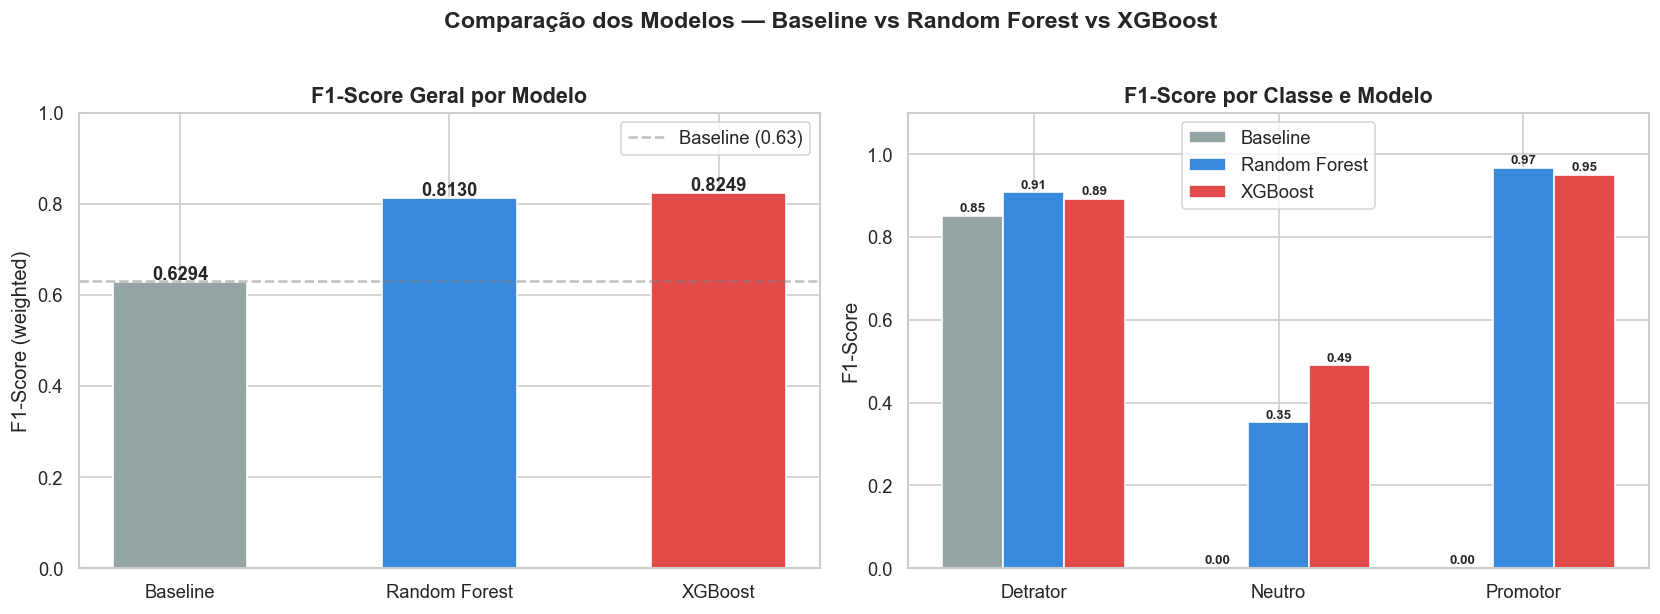


=== MODELO ESCOLHIDO ===
  XGBoost → F1 = 0.8249

  Justificativa:
  → Melhor F1-Score geral
  → Melhor identificação de Neutros (classe mais difícil)
  → +19.5% vs Baseline


In [7]:
# ============================================================
# SEÇÃO 7 - COMPARAÇÃO DOS MODELOS
# ============================================================

from sklearn.metrics import f1_score

# --- Calculando métricas por classe para cada modelo ---
modelos = {
    'Baseline': y_pred_baseline,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb
}

# F1 por classe
resultados = []
for nome, y_pred in modelos.items():
    f1_classes = f1_score(y_test, y_pred,
                          average=None,
                          labels=[0, 1, 2])
    f1_geral = f1_score(y_test, y_pred, average='weighted')
    resultados.append({
        'Modelo': nome,
        'F1 Geral': f1_geral,
        'F1 Detrator': f1_classes[0],
        'F1 Neutro': f1_classes[1],
        'F1 Promotor': f1_classes[2]
    })

df_resultados = pd.DataFrame(resultados)

print("=== COMPARAÇÃO GERAL DOS MODELOS ===\n")
print(df_resultados.to_string(index=False, float_format='{:.4f}'.format))

# --- Gráficos de comparação ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cores_modelos = ['#95A5A6', '#378ADD', '#E24B4A']

# Gráfico 1: F1 Geral
bars = axes[0].bar(df_resultados['Modelo'],
                   df_resultados['F1 Geral'],
                   color=cores_modelos, edgecolor='white', width=0.5)

for bar, val in zip(bars, df_resultados['F1 Geral']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.4f}',
                 ha='center', fontsize=11, fontweight='bold')

axes[0].set_title('F1-Score Geral por Modelo',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('F1-Score (weighted)')
axes[0].set_ylim(0, 1.0)
axes[0].axhline(0.63, color='gray', linestyle='--',
                alpha=0.5, label='Baseline (0.63)')
axes[0].legend()

# Gráfico 2: F1 por classe
x = np.arange(3)
width = 0.25
classes = ['F1 Detrator', 'F1 Neutro', 'F1 Promotor']

for i, (nome, cor) in enumerate(zip(df_resultados['Modelo'],
                                     cores_modelos)):
    valores = df_resultados.iloc[i][classes].values
    bars = axes[1].bar(x + i*width, valores,
                       width, label=nome,
                       color=cor, edgecolor='white')
    for bar, val in zip(bars, valores):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f'{val:.2f}',
                     ha='center', fontsize=8, fontweight='bold')

axes[1].set_title('F1-Score por Classe e Modelo',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1-Score')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(['Detrator', 'Neutro', 'Promotor'])
axes[1].set_ylim(0, 1.1)
axes[1].legend()

plt.suptitle('Comparação dos Modelos — Baseline vs Random Forest vs XGBoost',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/12_comparacao_modelos.png', bbox_inches='tight')
plt.show()

# Resumo da decisão
print("\n=== MODELO ESCOLHIDO ===")
melhor = df_resultados.loc[df_resultados['F1 Geral'].idxmax(), 'Modelo']
melhor_f1 = df_resultados['F1 Geral'].max()
print(f"  {melhor} → F1 = {melhor_f1:.4f}")
print(f"\n  Justificativa:")
print(f"  → Melhor F1-Score geral")
print(f"  → Melhor identificação de Neutros (classe mais difícil)")
print(f"  → +19.5% vs Baseline")

Calculando valores SHAP...
Shape original: (750, 15, 3)
Shape reorganizado: (3, 750, 15)

Gerando Summary Plot para classe Detrator...


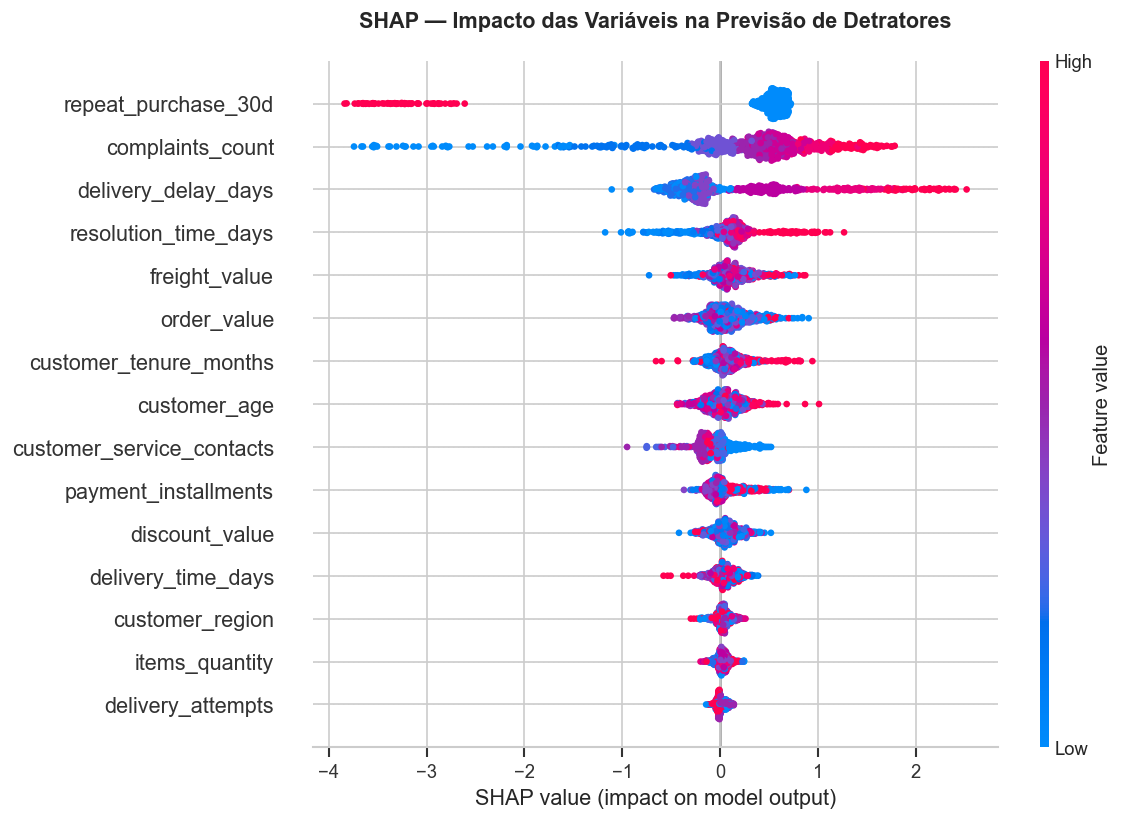

Gerando Summary Plot para classe Promotor...


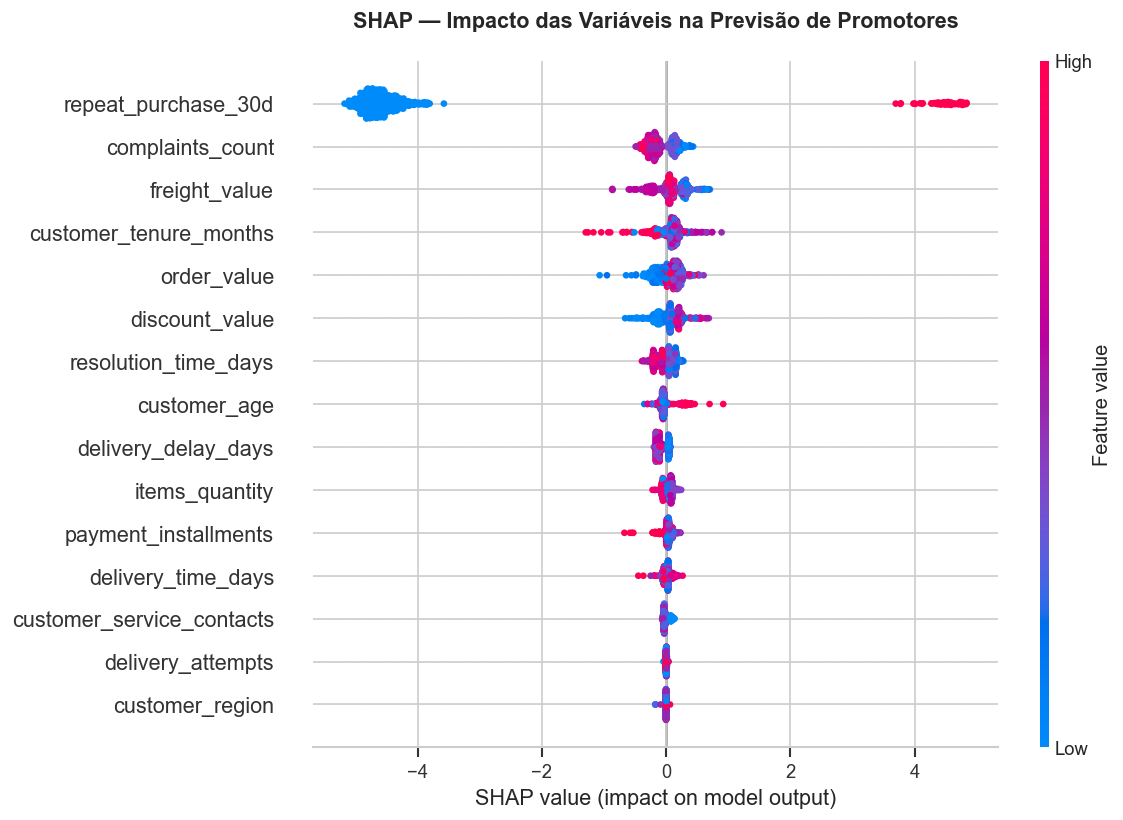


Análise SHAP concluída


In [10]:
# ============================================================
# SEÇÃO 8 - INTERPRETABILIDADE (SHAP)
# ============================================================

print("Calculando valores SHAP...")
shap_values = explainer.shap_values(X_test)
shap_array = np.array(shap_values)
print(f"Shape original: {shap_array.shape}")

# Reorganizando para formato correto
# (750, 15, 3) → precisamos de (3, 750, 15)
if shap_array.shape == (750, 15, 3):
    shap_reorganizado = np.transpose(shap_array, (2, 0, 1))
    print(f"Shape reorganizado: {shap_reorganizado.shape}")
else:
    shap_reorganizado = shap_array

# --- Summary Plot para Detratores (classe 0) ---
print("\nGerando Summary Plot para classe Detrator...")
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_reorganizado[0],
    X_test,
    feature_names=X.columns.tolist(),
    show=False,
    plot_size=(10, 7)
)
plt.title('SHAP — Impacto das Variáveis na Previsão de Detratores',
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../reports/figures/13_shap_detrator.png', bbox_inches='tight')
plt.show()

# --- Summary Plot para Promotores (classe 2) ---
print("Gerando Summary Plot para classe Promotor...")
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_reorganizado[2],
    X_test,
    feature_names=X.columns.tolist(),
    show=False,
    plot_size=(10, 7)
)
plt.title('SHAP — Impacto das Variáveis na Previsão de Promotores',
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../reports/figures/14_shap_promotor.png', bbox_inches='tight')
plt.show()

print("\nAnálise SHAP concluída")

In [12]:
# ============================================================
# SEÇÃO 9 - RESUMO E CONCLUSÕES DO MODELO
# ============================================================

print("=" * 65)
print("RESUMO DO MODELO PREDITIVO — NPS PREDITIVO")
print("=" * 65)

print("""
PROBLEMA DE NEGÓCIO
─────────────────────────────────────────────────────────────
Prever a categoria NPS do cliente (Detrator/Neutro/Promotor)
ANTES da aplicação da pesquisa, usando apenas dados
operacionais disponíveis durante a jornada de compra.

DECISÕES TÉCNICAS
─────────────────────────────────────────────────────────────
Tipo de problema:  Classificação multiclasse (3 classes)
Variável target:   nps_categoria (Detrator=0, Neutro=1, Promotor=2)
Divisão:           70% treino / 30% teste (stratified)
Balanceamento:     class_weight e sample_weight

Variáveis excluídas:
  × customer_id          → identificador
  × order_id             → identificador
  × nps_score            → origem da target (leakage)
  × csat_internal_score  → data leakage (r=0.564)

Variáveis utilizadas: 15 features operacionais

RESULTADOS DOS MODELOS
─────────────────────────────────────────────────────────────
  Baseline       → F1 = 0.6294  (referência mínima)
  Random Forest  → F1 = 0.8130  (+29% vs baseline)
  XGBoost        → F1 = 0.8249  (+31% vs baseline) ✅ ESCOLHIDO

PERFORMANCE DO MODELO FINAL (XGBoost)
─────────────────────────────────────────────────────────────
  Detrator   → Precision: 0.88 | Recall: 0.91 | F1: 0.89
  Neutro     → Precision: 0.54 | Recall: 0.45 | F1: 0.49
  Promotor   → Precision: 0.94 | Recall: 0.97 | F1: 0.95

  F1 weighted:  0.8249
  Acurácia:     0.8267

TOP 3 VARIÁVEIS MAIS IMPORTANTES (SHAP)
─────────────────────────────────────────────────────────────
  1. repeat_purchase_30d   → 78.5% do poder de decisão
     Recompra em 30 dias é o maior preditor de satisfação

  2. complaints_count      → 4.4%
     Mais reclamações = maior chance de Detrator

  3. delivery_delay_days   → 4.2%
     Atraso na entrega empurra fortemente para Detrator

LIMITAÇÕES E RISCOS
─────────────────────────────────────────────────────────────
  ⚠️  Classe Neutro ainda com F1 baixo (0.49)
      Clientes no meio da escala são naturalmente difíceis

  ⚠️  Dependência alta de repeat_purchase_30d (78.5% XGBoost)
      Modelo pode ser simplista para clientes novos
      que ainda não tiveram chance de recomprar

  ⚠️  Base desbalanceada (74% Detratores)
      Resultados podem variar em bases mais equilibradas

  ⚠️  Dados fictícios para fins educativos
      Validação em dados reais é necessária antes
      de implementar em produção

COMO USAR NA PRÁTICA
─────────────────────────────────────────────────────────────
  1. Após cada entrega, coletar os dados operacionais
  2. Aplicar o modelo para prever a categoria NPS
  3. Clientes previstos como Detrator → ação imediata
     → CS entra em contato proativamente
     → Oferecer compensação ou solução antes da pesquisa
  4. Monitorar se a intervenção converteu Detratores
     em Neutros ou Promotores
  5. Retreinar o modelo periodicamente com novos dados
""")

print("=" * 65)
print("FIM DO MODELO PREDITIVO")
print("=" * 65)

RESUMO DO MODELO PREDITIVO — NPS PREDITIVO

PROBLEMA DE NEGÓCIO
─────────────────────────────────────────────────────────────
Prever a categoria NPS do cliente (Detrator/Neutro/Promotor)
ANTES da aplicação da pesquisa, usando apenas dados
operacionais disponíveis durante a jornada de compra.

DECISÕES TÉCNICAS
─────────────────────────────────────────────────────────────
Tipo de problema:  Classificação multiclasse (3 classes)
Variável target:   nps_categoria (Detrator=0, Neutro=1, Promotor=2)
Divisão:           70% treino / 30% teste (stratified)
Balanceamento:     class_weight e sample_weight

Variáveis excluídas:
  × customer_id          → identificador
  × order_id             → identificador
  × nps_score            → origem da target (leakage)
  × csat_internal_score  → data leakage (r=0.564)

Variáveis utilizadas: 15 features operacionais

RESULTADOS DOS MODELOS
─────────────────────────────────────────────────────────────
  Baseline       → F1 = 0.6294  (referência mínima)
  Ra

=== MOTIVAÇÃO ===
repeat_purchase_30d só é conhecido 30 dias após a entrega.
O modelo precisa prever ANTES disso — testando sem ela.

Variáveis removidas: ['repeat_purchase_30d']
Variáveis restantes: 14
['customer_age', 'customer_region', 'customer_tenure_months', 'order_value', 'items_quantity', 'discount_value', 'payment_installments', 'delivery_time_days', 'delivery_delay_days', 'freight_value', 'delivery_attempts', 'customer_service_contacts', 'resolution_time_days', 'complaints_count']

Treinando XGBoost v2 (sem repeat_purchase_30d)...

=== XGBOOST v2 — SEM repeat_purchase_30d ===

              precision    recall  f1-score   support

    Detrator       0.86      0.89      0.88       555
      Neutro       0.41      0.39      0.40       135
    Promotor       0.29      0.23      0.26        60

    accuracy                           0.75       750
   macro avg       0.52      0.51      0.51       750
weighted avg       0.74      0.75      0.74       750

F1-Score (weighted): 0.74

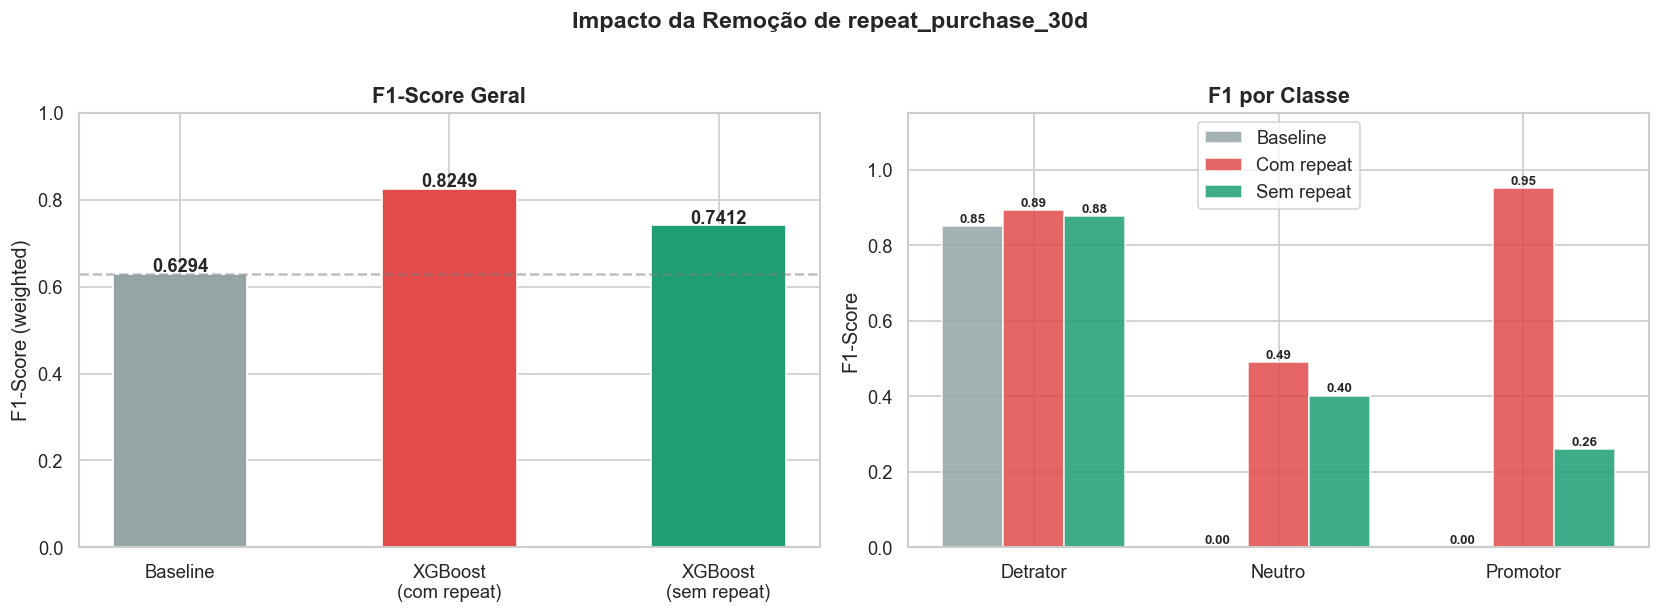


=== CONCLUSÃO ===
  Queda de 0.0838 pontos no F1
  → Queda relevante — repeat_purchase_30d é importante
  → Recomendação: usar com ressalva sobre disponibilidade


In [13]:
# ============================================================
# SEÇÃO 10 - MODELO SEM repeat_purchase_30d
# (teste de viabilidade para uso em produção)
# ============================================================

print("=== MOTIVAÇÃO ===")
print("repeat_purchase_30d só é conhecido 30 dias após a entrega.")
print("O modelo precisa prever ANTES disso — testando sem ela.\n")

# --- Removendo repeat_purchase_30d ---
colunas_modelo_v2 = [c for c in X.columns if c != 'repeat_purchase_30d']
print(f"Variáveis removidas: ['repeat_purchase_30d']")
print(f"Variáveis restantes: {len(colunas_modelo_v2)}")
print(f"{colunas_modelo_v2}\n")

# --- Nova separação treino/teste ---
X2_train = X_train[colunas_modelo_v2]
X2_test  = X_test[colunas_modelo_v2]

# --- Retreinando XGBoost sem repeat_purchase_30d ---
print("Treinando XGBoost v2 (sem repeat_purchase_30d)...")

xgb_v2 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    verbosity=0
)
xgb_v2.fit(X2_train, y_train, sample_weight=sample_weights)
y_pred_xgb_v2 = xgb_v2.predict(X2_test)

print("\n=== XGBOOST v2 — SEM repeat_purchase_30d ===\n")
print(classification_report(
    y_test, y_pred_xgb_v2,
    target_names=le_target.classes_))

f1_xgb_v2 = f1_score(y_test, y_pred_xgb_v2, average='weighted')
print(f"F1-Score (weighted): {f1_xgb_v2:.4f}")

# --- Comparação direta ---
print("\n=== COMPARAÇÃO DIRETA ===\n")
print(f"{'Modelo':<35} {'F1 Geral':>10} {'F1 Neutro':>10} {'F1 Promotor':>10}")
print("-" * 67)

modelos_comp = {
    'Baseline':                    (f1_baseline, 0.00, 0.00),
    'XGBoost (com repeat_purchase)': (f1_xgb, 0.49, 0.95),
    'XGBoost (sem repeat_purchase)': (f1_xgb_v2,
        f1_score(y_test, y_pred_xgb_v2, average=None)[1],
        f1_score(y_test, y_pred_xgb_v2, average=None)[2])
}

for nome, (f1g, f1n, f1p) in modelos_comp.items():
    print(f"{nome:<35} {f1g:>10.4f} {f1n:>10.4f} {f1p:>10.4f}")

# --- Gráfico comparativo ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nomes = ['Baseline', 'XGBoost\n(com repeat)', 'XGBoost\n(sem repeat)']
f1_gerais = [f1_baseline, f1_xgb, f1_xgb_v2]
cores_comp = ['#95A5A6', '#E24B4A', '#1D9E75']

bars = axes[0].bar(nomes, f1_gerais,
                   color=cores_comp, edgecolor='white', width=0.5)
for bar, val in zip(bars, f1_gerais):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.4f}',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('F1-Score Geral', fontsize=13, fontweight='bold')
axes[0].set_ylabel('F1-Score (weighted)')
axes[0].set_ylim(0, 1.0)
axes[0].axhline(f1_baseline, color='gray', linestyle='--', alpha=0.5)

# F1 por classe
x = np.arange(3)
width = 0.25
classes_labels = ['Detrator', 'Neutro', 'Promotor']

for i, (nome, cor) in enumerate(zip(
        ['Baseline', 'Com repeat', 'Sem repeat'],
        cores_comp)):
    if nome == 'Baseline':
        valores = [0.85, 0.00, 0.00]
    elif nome == 'Com repeat':
        valores = list(f1_score(y_test, y_pred_xgb,
                                average=None, labels=[0,1,2]))
    else:
        valores = list(f1_score(y_test, y_pred_xgb_v2,
                                average=None, labels=[0,1,2]))

    bars = axes[1].bar(x + i*width, valores,
                       width, label=nome,
                       color=cor, edgecolor='white', alpha=0.85)
    for bar, val in zip(bars, valores):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f'{val:.2f}',
                     ha='center', fontsize=8, fontweight='bold')

axes[1].set_title('F1 por Classe', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1-Score')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(classes_labels)
axes[1].set_ylim(0, 1.15)
axes[1].legend()

plt.suptitle('Impacto da Remoção de repeat_purchase_30d',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/15_comparacao_sem_repeat.png',
            bbox_inches='tight')
plt.show()

# Conclusão automática
print("\n=== CONCLUSÃO ===")
diff = f1_xgb - f1_xgb_v2
if diff < 0.05:
    print(f"  Queda de apenas {diff:.4f} pontos no F1")
    print(f"  → Modelo sem repeat_purchase_30d é VIÁVEL para produção")
    print(f"  → Recomendação: usar versão sem repeat para uso real")
else:
    print(f"  Queda de {diff:.4f} pontos no F1")
    print(f"  → Queda relevante — repeat_purchase_30d é importante")
    print(f"  → Recomendação: usar com ressalva sobre disponibilidade")